Какие данные у нас есть?

In [1]:
import pandas as pd
import requests
import json

Посмотрим таблицу продаж, построим графики

In [2]:
url = 'https://raw.githubusercontent.com/valentinesvev/hackaton_project/main/data/raw/base.csv' # таблица из условия

In [3]:
base = pd.read_csv(url, on_bad_lines='warn')

In [4]:
base

,Номер студента,Сумма,Курс,Время
0,437,"8 950,00",ML про,04.08.2026 09:08:31
1,437,"7 890,00",Аналитика старт,04.08.2026 09:35:00
2,443,"8 475,00",Линейная алгебра,04.08.2026 10:14:38
3,443,"8 475,00",Мат анализ,04.08.2026 10:14:38
4,430,"8 950,00",К ВУЗу,04.08.2026 13:38:06
...,...,...,...,...
790,36,"8 950,00",Линейная алгебра,09.09.2026 19:26:20
791,36,"8 950,00",Мат анализ,09.09.2026 19:26:20
792,36,"8 950,00",Теория вероятностей,09.09.2026 19:26:20
793,407,"8 950,00",Линейная алгебра,09.09.2026 23:11:20


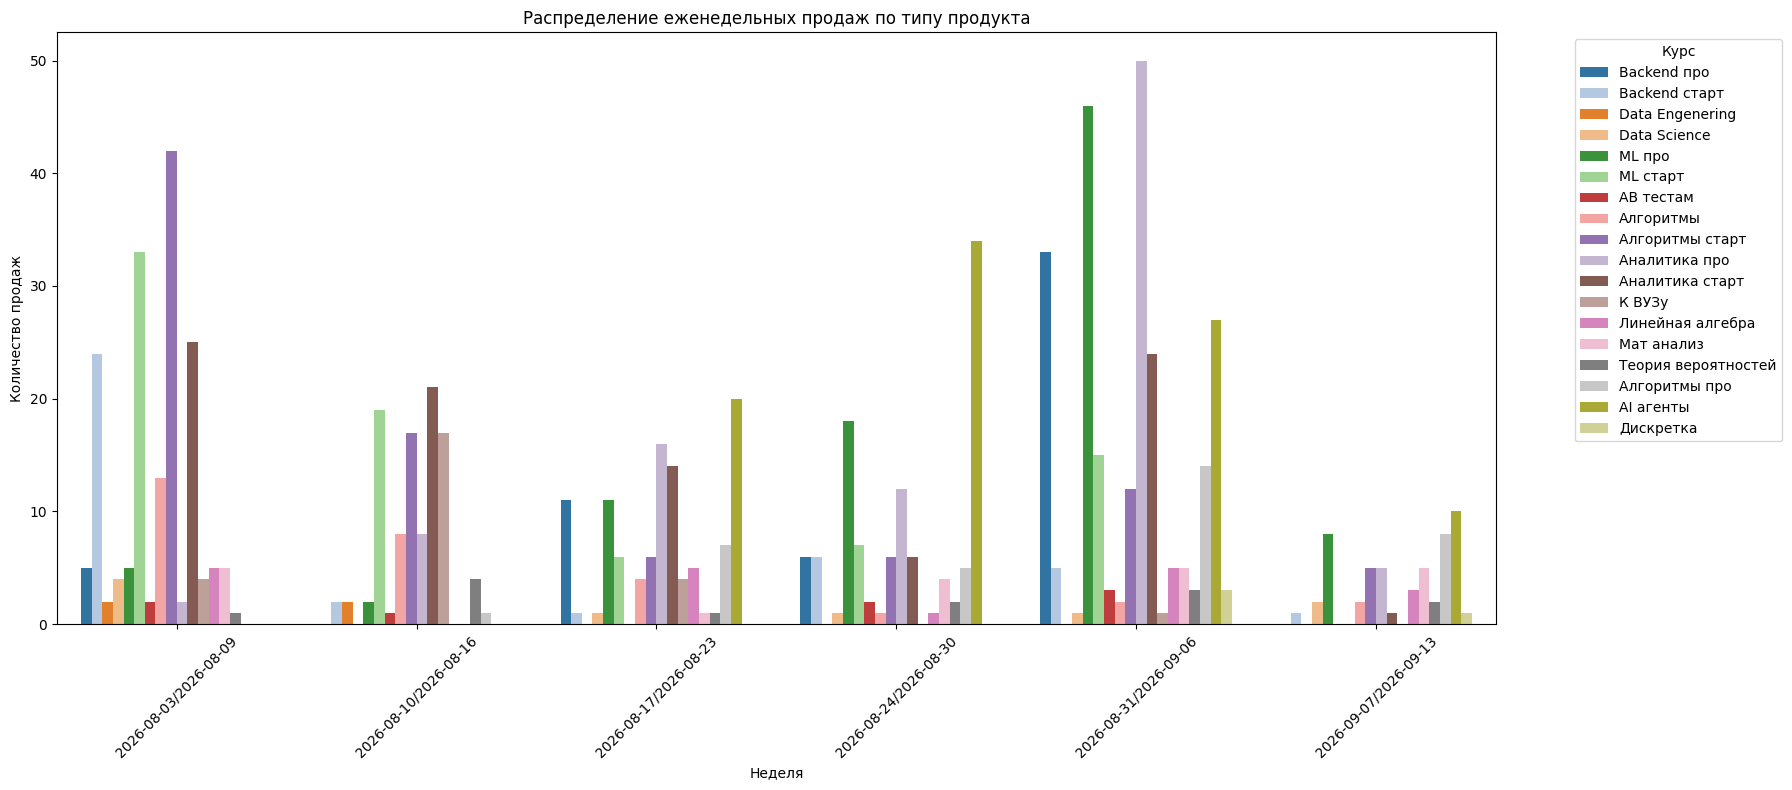

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Время' to datetime objects (if not already converted)
base['Время'] = pd.to_datetime(base['Время'], format='%d.%m.%Y %H:%M:%S', errors='coerce')

# Extract week for weekly sales count
base['Неделя'] = base['Время'].dt.to_period('W')

# Group by week and product type ('Курс') and count sales
weekly_sales_by_product = base.groupby(['Неделя', 'Курс']).size().reset_index(name='Количество продаж')

# Convert Period to string for plotting
weekly_sales_by_product['Неделя'] = weekly_sales_by_product['Неделя'].astype(str)

# Plotting a bar plot of weekly sales by product type
plt.figure(figsize=(18, 8))
sns.barplot(x='Неделя', y='Количество продаж', hue='Курс', data=weekly_sales_by_product, palette='tab20', dodge=True)
plt.title('Распределение еженедельных продаж по типу продукта')
plt.xlabel('Неделя')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.legend(title='Курс', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
base_cleaned = base.copy()

# Clean and convert 'Сумма' to numeric, handling non-breaking spaces
base_cleaned['Сумма'] = base_cleaned['Сумма'].str.replace(r'\s', '', regex=True).str.replace(',', '.').astype(float)

# 1. Total revenue
total_revenue = base_cleaned['Сумма'].sum()

# 2. Number of transactions
num_transactions = base_cleaned.shape[0]

# 3. Number of unique clients
unique_clients = base_cleaned['Номер студента'].nunique()

# 4. Average check
average_check = base_cleaned['Сумма'].mean()

# 5. Median check
median_check = base_cleaned['Сумма'].median()

# 6. Number of products
num_products = base_cleaned['Курс'].nunique()

# 7. Share of customers with repeat purchases
# Count transactions per client
transactions_per_client = base_cleaned['Номер студента'].value_counts()

# Identify clients with more than one transaction
repeat_buyers = transactions_per_client[transactions_per_client > 1].count()

# Calculate the share of repeat buyers
share_repeat_buyers = (repeat_buyers / unique_clients) * 100 if unique_clients > 0 else 0

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Number of Transactions: {num_transactions}")
print(f"Number of Unique Clients: {unique_clients}")
print(f"Average Check: {average_check:,.2f}")
print(f"Median Check: {median_check:,.2f}")
print(f"Number of Unique Products: {num_products}")
print(f"Share of Clients with Repeat Purchases: {share_repeat_buyers:.2f}%")

Total Revenue: 5,904,671.67
Number of Transactions: 795
Number of Unique Clients: 606
Average Check: 7,427.26
Median Check: 7,475.00
Number of Unique Products: 18
Share of Clients with Repeat Purchases: 26.90%


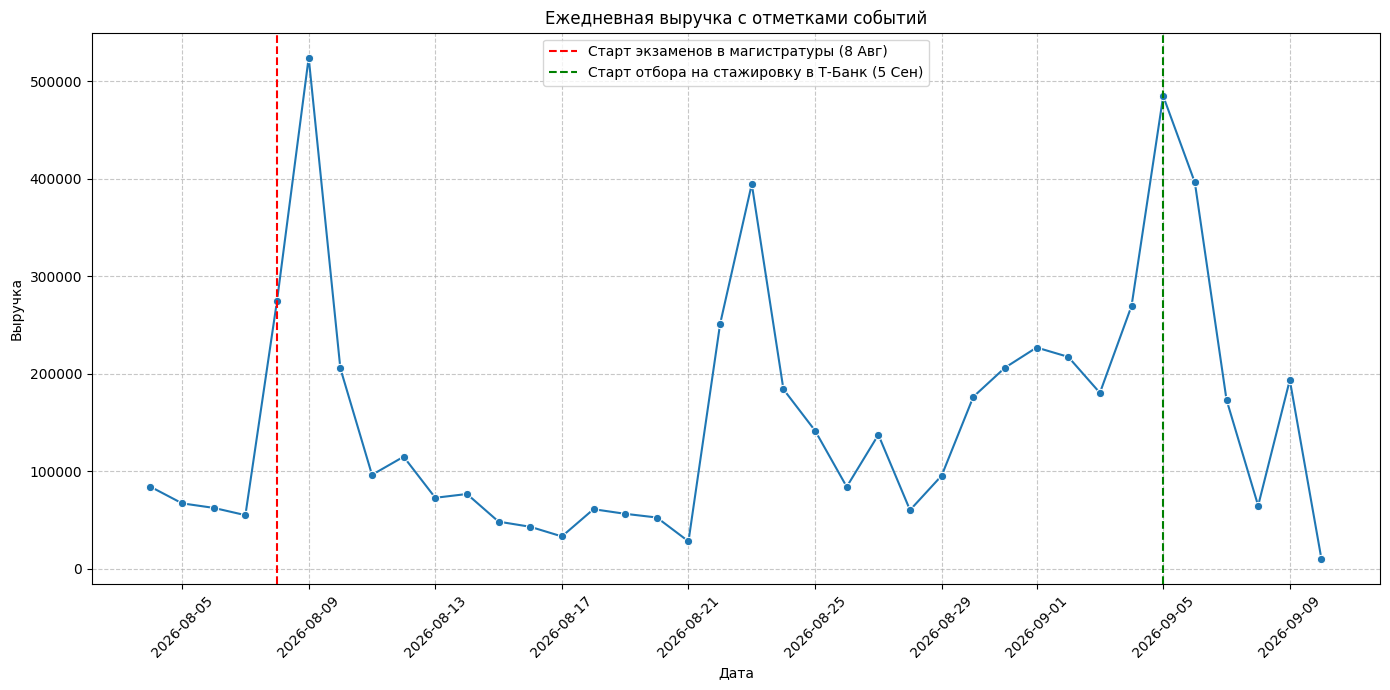

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Время' is datetime and then extract the date
base_cleaned['Время'] = pd.to_datetime(base_cleaned['Время'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
base_cleaned['День'] = base_cleaned['Время'].dt.date

# Group by day and sum the 'Сумма' for daily revenue
daily_revenue = base_cleaned.groupby('День')['Сумма'].sum().reset_index()

# Plotting the daily revenue
plt.figure(figsize=(14, 7))
sns.lineplot(x='День', y='Сумма', data=daily_revenue, marker='o')

# Add vertical lines for specific dates
exam_start_date = pd.to_datetime('2026-08-08').date()
internship_start_date = pd.to_datetime('2026-09-05').date()

plt.axvline(x=exam_start_date, color='r', linestyle='--', label='Старт экзаменов в магистратуры (8 Авг)')
plt.axvline(x=internship_start_date, color='g', linestyle='--', label='Старт отбора на стажировку в Т-Банк (5 Сен)')

plt.title('Ежедневная выручка с отметками событий')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

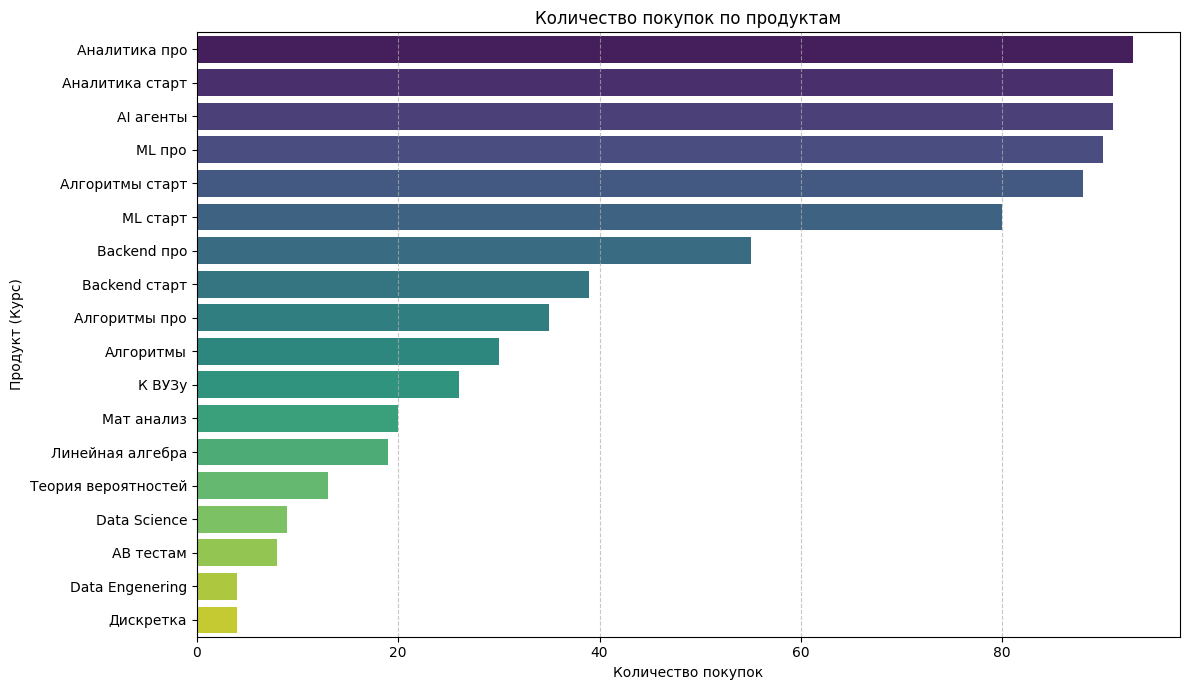

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Курс' and count the number of purchases for each course
product_purchases = base_cleaned['Курс'].value_counts().reset_index()
product_purchases.columns = ['Курс', 'Количество покупок']

# Plotting the number of purchases by product
plt.figure(figsize=(12, 7))
sns.barplot(x='Количество покупок', y='Курс', hue='Курс', data=product_purchases, palette='viridis', legend=False)
plt.title('Количество покупок по продуктам')
plt.xlabel('Количество покупок')
plt.ylabel('Продукт (Курс)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
top_6_products = product_revenue_sorted.head(6)
display(top_6_products)

,Курс,Сумма
11,Аналитика про,740941.50
5,ML про,715110.00
0,AI агенты,711673.00
12,Аналитика старт,641616.50
10,Алгоритмы старт,529851.68
6,ML старт,523278.33


In [16]:
top_6_revenue = top_6_products['Сумма'].sum()
percentage_top_6_revenue = (top_6_revenue / total_revenue) * 100

print(f"Топ-6 продуктов формируют {percentage_top_6_revenue:.2f}% от общей выручки.")

Топ-6 продуктов формируют 65.41% от общей выручки.


Вывод: приемная кампания в бакалавриат и студ сессии в даты исследования не попали, возможно в июне другие продукты делают основную выручку. А возможно нет

### Анализ новых и повторных клиентов

In [17]:
# Определяем дату первой покупки для каждого клиента
first_purchase = base_cleaned.groupby('Номер студента')['Время'].min().reset_index()
first_purchase.rename(columns={'Время': 'Дата первой покупки'}, inplace=True)

# Объединяем с основным DataFrame, чтобы получить дату первой покупки для каждой транзакции
base_with_first_purchase = pd.merge(base_cleaned, first_purchase, on='Номер студента', how='left')

# Отфильтровываем транзакции, которые являются первой покупкой
# Теперь 'Время' в `base_with_first_purchase` относится к конкретной транзакции,
# а 'Дата первой покупки' - к самой первой транзакции клиента.
# Мы ищем транзакции, которые произошли *после* первой покупки, чтобы найти вторую.

# Для клиентов с повторными покупками находим вторую покупку
# Сначала отфильтруем все транзакции, кроме первой для каждого клиента
subsequent_purchases = base_with_first_purchase[base_with_first_purchase['Время'] > base_with_first_purchase['Дата первой покупки']]

# Если есть несколько последующих покупок, берем ближайшую (вторую по порядку)
second_purchase = subsequent_purchases.groupby('Номер студента')['Время'].min().reset_index()
second_purchase.rename(columns={'Время': 'Дата второй покупки'}, inplace=True)

# Объединяем даты первой и второй покупки для клиентов с повторными покупками
repeat_customer_dates = pd.merge(first_purchase, second_purchase, on='Номер студента', how='inner')

# Рассчитываем время между первой и второй покупками
repeat_customer_dates['Время между покупками'] = (repeat_customer_dates['Дата второй покупки'] - repeat_customer_dates['Дата первой покупки'])

display(repeat_customer_dates.head())

,Номер студента,Дата первой покупки,Дата второй покупки,Время между покупками
0,26,2026-08-08 09:23:01,2026-08-31 14:03:44,23 days 04:40:43
1,63,2026-08-09 19:29:08,2026-09-07 05:24:57,28 days 09:55:49
2,67,2026-08-10 18:01:06,2026-09-05 17:04:40,25 days 23:03:34
3,138,2026-08-09 16:33:22,2026-08-25 12:39:08,15 days 20:05:46
4,144,2026-08-29 11:51:08,2026-09-01 15:30:39,3 days 03:39:31


### Статистика времени между первой и второй покупками

Статистика времени между первой и второй покупками:


,Время между покупками
count,20
mean,13 days 06:03:53.200000
std,10 days 19:12:48.715013562
min,0 days 00:26:29
25%,2 days 09:04:10
50%,12 days 22:38:29.500000
75%,24 days 04:19:42.500000
max,28 days 12:40:07


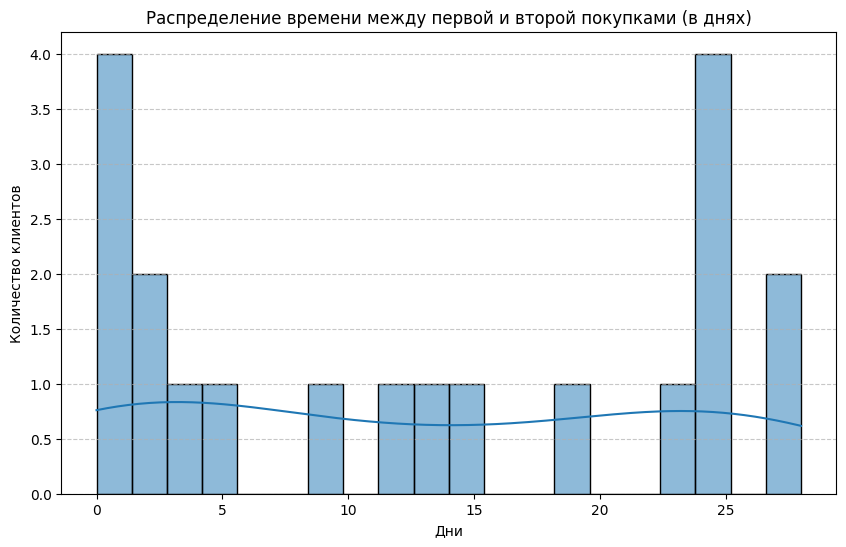

In [18]:
# Статистика по времени между первой и второй покупками
print("Статистика времени между первой и второй покупками:")
display(repeat_customer_dates['Время между покупками'].describe())

# Визуализация распределения времени между покупками (в днях)
plt.figure(figsize=(10, 6))
sns.histplot(repeat_customer_dates['Время между покупками'].dt.days, bins=20, kde=True)
plt.title('Распределение времени между первой и второй покупками (в днях)')
plt.xlabel('Дни')
plt.ylabel('Количество клиентов')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Интересно, среднее время 2 недели, те люди возмращаются после курсов. Хорошие должно быть курсы

Выгрузили все посты из тг канала, соберем удобную таблицу

In [19]:
url = "https://raw.githubusercontent.com/valentinesvev/hackaton_project/main/data/raw/tg_posts_text.json" # выгрузка постов поступашек

data = requests.get(url).json()

print(type(data))

if isinstance(data, dict):
    print(data.keys())

<class 'dict'>
dict_keys(['name', 'type', 'id', 'messages'])


In [20]:
posts = data["messages"]

In [21]:
data['messages'][25]

{'id': 27,
 'type': 'message',
 'date': '2022-02-19T09:54:18',
 'date_unixtime': '1645253658',
 'edited': '2022-04-18T07:02:34',
 'edited_unixtime': '1650254554',
 'from': 'Поступашки - ШАД, Стажировки и Магистратура',
 'from_id': 'channel1756387595',
 'photo': '(File not included. Change data exporting settings to download.)',
 'photo_file_size': 60318,
 'width': 900,
 'height': 500,
 'text': 'Физтехи Lives Matter ✊',
 'text_entities': [{'type': 'plain', 'text': 'Физтехи Lives Matter ✊'}],
 'reactions': [{'type': 'emoji', 'count': 6, 'emoji': '👍'}]}

In [22]:
df = pd.json_normalize(posts)

print(df.columns.tolist())
df.head()

['id', 'type', 'date', 'date_unixtime', 'actor', 'actor_id', 'action', 'title', 'text', 'text_entities', 'photo', 'photo_file_size', 'width', 'height', 'edited', 'edited_unixtime', 'from', 'from_id', 'reactions', 'file', 'file_name', 'file_size', 'media_type', 'mime_type', 'duration_seconds', 'thumbnail', 'thumbnail_file_size', 'message_id', 'forwarded_from', 'forwarded_from_id', 'poll.question', 'poll.closed', 'poll.total_voters', 'poll.answers', 'inline_bot_buttons']


,id,type,date,date_unixtime,actor,actor_id,action,title,text,text_entities,...,thumbnail,thumbnail_file_size,message_id,forwarded_from,forwarded_from_id,poll.question,poll.closed,poll.total_voters,poll.answers,inline_bot_buttons
0,1,service,2022-01-31T14:12:32,1643627552,"Поступашки - ШАД, Стажировки и Магистратура",channel1756387595,create_channel,"Поступашки - ШАД, Стажировки",,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,service,2022-01-31T14:12:32,1643627552,"Поступашки - ШАД, Стажировки и Магистратура",channel1756387595,edit_group_photo,NaN,,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,service,2022-02-01T13:40:33,1643712033,"Поступашки - ШАД, Стажировки и Магистратура",channel1756387595,edit_group_title,"Поступашки - ШАД, Стажировки и Магистратура",,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,message,2022-02-12T20:26:12,1644686772,NaN,NaN,NaN,NaN,"[Наслаждаемся моим первым опытом 😎, {'type': ...","[{'type': 'plain', 'text': 'Наслаждаемся моим ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,message,2022-02-13T21:11:10,1644775870,NaN,NaN,NaN,NaN,Школа Анализа Данных не одна?😱 \n \nВсё слышал...,"[{'type': 'plain', 'text': 'Школа Анализа Данн...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
def clean_text(value):
    if isinstance(value, list):
        return " ".join(
            item.get("text", "") if isinstance(item, dict) else str(item)
            for item in value
        )
    return str(value) if value is not None else ""

events = pd.DataFrame({
    "event_id": "tg_post_" + df["id"].astype(str),
    "event_type": "channel_post_published",
    "event_timestamp": pd.to_datetime(df["date"]),
    "channel": "postupashki",
    "post_id": df["id"],
    "post_text": df["text"].apply(clean_text),
    "views": df["views"] if "views" in df.columns else None,
    "forwards": df["forwards"] if "forwards" in df.columns else None,
    "source": "telegram_export",
    "is_real_data": True
})

events.head()

,event_id,event_type,event_timestamp,channel,post_id,post_text,views,forwards,source,is_real_data
0,tg_post_1,channel_post_published,2022-01-31 14:12:32,postupashki,1,,None,None,telegram_export,True
1,tg_post_2,channel_post_published,2022-01-31 14:12:32,postupashki,2,,None,None,telegram_export,True
2,tg_post_3,channel_post_published,2022-02-01 13:40:33,postupashki,3,,None,None,telegram_export,True
3,tg_post_5,channel_post_published,2022-02-12 20:26:12,postupashki,5,Наслаждаемся моим первым опытом 😎 https://www...,None,None,telegram_export,True
4,tg_post_6,channel_post_published,2022-02-13 21:11:10,postupashki,6,Школа Анализа Данных не одна?😱 \n \nВсё слышал...,None,None,telegram_export,True


In [ ]:
events.to_csv("own_channel_events.csv", index=False)

In [24]:
events["post_type"] = "content"

In [25]:
events

,event_id,event_type,event_timestamp,channel,post_id,post_text,views,forwards,source,is_real_data,post_type
0,tg_post_1,channel_post_published,2022-01-31 14:12:32,postupashki,1,,None,None,telegram_export,True,content
1,tg_post_2,channel_post_published,2022-01-31 14:12:32,postupashki,2,,None,None,telegram_export,True,content
2,tg_post_3,channel_post_published,2022-02-01 13:40:33,postupashki,3,,None,None,telegram_export,True,content
3,tg_post_5,channel_post_published,2022-02-12 20:26:12,postupashki,5,Наслаждаемся моим первым опытом 😎 https://www...,None,None,telegram_export,True,content
4,tg_post_6,channel_post_published,2022-02-13 21:11:10,postupashki,6,Школа Анализа Данных не одна?😱 \n \nВсё слышал...,None,None,telegram_export,True,content
...,...,...,...,...,...,...,...,...,...,...,...
1224,tg_post_1895,channel_post_published,2026-09-08 18:27:01,postupashki,1895,Собрали все задачи с алгосекции в Яндексе в од...,None,None,telegram_export,True,content
1225,tg_post_1897,channel_post_published,2026-09-09 17:17:20,postupashki,1897,Как готовиться к софт собесам в Авито \n\nОчен...,None,None,telegram_export,True,content
1226,tg_post_1898,channel_post_published,2026-09-10 11:59:39,postupashki,1898,"Как хакнуть HR \n\nВ рамках открытой недели ""...",None,None,telegram_export,True,content
1227,tg_post_1899,channel_post_published,2026-09-10 17:06:13,postupashki,1899,Продолжаем знакомиться с талантливыми ученикам...,None,None,telegram_export,True,content


In [26]:
# оставим только данные после 4 августа, тк ранее данных о продажах нет
analysis_posts = events[
    (events["event_timestamp"] >= "2026-08-04") &
    (events["event_timestamp"] <= "2026-09-10 23:59:59")
].copy()

analysis_posts.shape

(63, 11)

In [27]:
analysis_posts # нормальная таблица всех постов с 4 августа

,event_id,event_type,event_timestamp,channel,post_id,post_text,views,forwards,source,is_real_data,post_type
1165,tg_post_1829,channel_post_published,2026-08-04 18:50:24,postupashki,1829,"C какими айтишницами стоит строить отношения, ...",None,None,telegram_export,True,content
1166,tg_post_1830,channel_post_published,2026-08-05 19:03:53,postupashki,1830,Как повысить профессиональный рейтинг \n\nРан...,None,None,telegram_export,True,content
1167,tg_post_1831,channel_post_published,2026-08-06 19:23:59,postupashki,1831,Какие пет проекты гарантирует тебе оффер на мл...,None,None,telegram_export,True,content
1168,tg_post_1833,channel_post_published,2026-08-07 17:22:16,postupashki,1833,Слив алгоритмического собеса в Авито. Смотрим!...,None,None,telegram_export,True,content
1169,tg_post_1834,channel_post_published,2026-08-08 09:05:37,postupashki,1834,Магистратура по e-commerce от РУДН и Wildberri...,None,None,telegram_export,True,content
...,...,...,...,...,...,...,...,...,...,...,...
1223,tg_post_1894,channel_post_published,2026-09-07 18:51:57,postupashki,1894,,None,None,telegram_export,True,content
1224,tg_post_1895,channel_post_published,2026-09-08 18:27:01,postupashki,1895,Собрали все задачи с алгосекции в Яндексе в од...,None,None,telegram_export,True,content
1225,tg_post_1897,channel_post_published,2026-09-09 17:17:20,postupashki,1897,Как готовиться к софт собесам в Авито \n\nОчен...,None,None,telegram_export,True,content
1226,tg_post_1898,channel_post_published,2026-09-10 11:59:39,postupashki,1898,"Как хакнуть HR \n\nВ рамках открытой недели ""...",None,None,telegram_export,True,content


In [ ]:
analysis_posts.to_csv("analysis_posts.csv")

In [ ]:
# Просмотры внесу руками, если надо

In [ ]:
# поиск рекламных постов по ключевым словам

keywords = r"курс|набор|запуск|скидк|промокод|цена|стоимость|купить|записат|оплат|регистрац"

ads = analysis_posts[
    analysis_posts["post_text"].str.contains(keywords, case=False, na=False)
].copy()

ads.shape

(31, 11)

In [ ]:
ads[["event_timestamp", "post_text"]]

,event_timestamp,post_text
1168,2026-08-07 17:22:16,Слив алгоритмического собеса в Авито. Смотрим!...
1169,2026-08-08 09:05:37,Магистратура по e-commerce от РУДН и Wildberri...
1170,2026-08-09 13:32:11,"Дайджест вакансий \n\nТоварищи, собрали свежие..."
1171,2026-08-09 18:35:40,"Как найти стажировку зарубежом \n\nТоварищи, п..."
1172,2026-08-10 16:26:59,Из процесс-менеджера в продуктового аналитика ...
1174,2026-08-10 20:33:06,"У России три пути: 18+, ***** и IT\n \nИ кажет..."
1176,2026-08-11 15:03:39,План на следующий учебный год: запустить IT-пр...
1177,2026-08-11 18:50:13,Как искать работу в 2026 году \n\nУже писал пр...
1178,2026-08-12 19:05:42,Гайд на собесы в СберЗвук Data Analyst \n\nВып...
1179,2026-08-13 10:05:42,"Товарищи, появился неплохой шанс прокачать сво..."


In [ ]:
# Была ли пересылка постов канала

[col for col in df.columns if "forward" in col.lower() or "via" in col.lower()]
# не было

['forwarded_from', 'forwarded_from_id']

In [28]:
import re

def classify_and_extract(row):
    text = str(row['post_text']).lower()

    # Initialize fields
    post_type = 'content'
    product = None
    discount = None
    campaign = None
    creative = None # Creative field is complex and left as None for now

    # 1. Determine post_type (hierarchical classification)

    # Check for discount keywords
    discount_keywords = ["скидка", "промокод", "акция", "распродажа", "спецпредложение", "бесплатно", "free"]
    if any(keyword in text for keyword in discount_keywords) or re.search(r'\d{1,3}%', text):
        post_type = 'discount'
        # Extract discount value
        discount_match = re.search(r'(\d{1,3}%)|(скидка \d{1,2})|(промокод [\w-]+)|(бесплатно)|(free)', text)
        if discount_match:
            discount = discount_match.group(0)

    # Check for external_ad (only if not already discount)
    # Criteria: Mentions known external companies and promotion-related keywords (internship, selection, etc.)
    external_companies_keywords = ["яндекс", "авито", "т-банк", "сбер", "рудн", "wildberries", "hh.ru", "linkedin"]
    external_promo_keywords = ["отбор", "стажировка", "вакансия", "олимпиада", "магистратура", "программа", "курс", "мероприятие"]

    if post_type == 'content' and any(comp in text for comp in external_companies_keywords) and \
       any(promo_kwd in text for promo_kwd in external_promo_keywords):
        post_type = 'external_ad'
        # Specific campaign extraction for external ads
        if "стажировка в т-банк" in text:
            campaign = "Стажировка в Т-Банк"
        elif "яндекс" in text and "олимпиада" in text:
            campaign = "Олимпиада Яндекс"
        elif "магистратура" in text and ("рудн" in text or "wildberries" in text):
            campaign = "Магистратура РУДН/Wildberries"
        elif "hh.ru" in text or "linkedin" in text:
            campaign = "Вакансии на внешних платформах"

    # Check for sale (only if not already discount or external_ad)
    # These are posts promoting 'Поступашки' internal products/events
    sale_keywords = ["курс", "набор", "запуск", "записаться", "купить", "старт", "вебинар", "мастер-класс",
                     "регистрация", "программа", "обучение", "отбор", "дедлайн", "мероприятие", "открытая неделя"]
    if post_type == 'content' and any(keyword in text for keyword in sale_keywords):
        post_type = 'sale'

    # 2. Extract product (from 'base_cleaned' courses)
    unique_courses = base_cleaned['Курс'].unique().tolist()
    # Sort by length descending to match longer course names first
    escaped_courses = [re.escape(c) for c in unique_courses]
    product_pattern = re.compile(r'\b(?:' + '|'.join(sorted(escaped_courses, key=len, reverse=True)) + r')\b', re.IGNORECASE)

    product_match = product_pattern.search(row['post_text'])
    if product_match:
        product = product_match.group(0)
        # Heuristic for 'native' post_type: if it's 'content' but a product is mentioned, it's native promotion
        if post_type == 'content': # This means it wasn't discount, external_ad, or explicit sale
            post_type = 'native'

    # 3. Extract campaign (if not already set by external_ad logic)
    if not campaign:
        if "хакатон" in text:
            campaign = "Хакатон"
        elif "открытая неделя" in text or "открытой недели" in text:
            campaign = "Открытая неделя"
        elif "магистратура" in text and product: # if a specific 'Поступашки' product is also a magistracy
            campaign = f"Магистратура {product}"
        elif "стажировка" in text and product:
            campaign = f"Стажировка {product}"
        elif "олимпиада" in text:
            campaign = "Олимпиада"
        elif "план на следующий учебный год" in text:
            campaign = "План учебного года"
        elif "собес" in text:
            campaign = "Подготовка к собеседованиям"
        # General campaign for specific products if applicable
        elif product:
            campaign = f"Продвижение {product}"

    return post_type, product, discount, campaign, row['channel'], creative # Use existing channel for 'channel'

# Apply the classification function
analysis_posts_classified = analysis_posts.copy() # Work on a copy to avoid SettingWithCopyWarning

# Apply the classification and extraction function to create new columns
analysis_posts_classified[['post_type', 'product', 'discount', 'campaign', 'channel_extracted', 'creative']] = \
    analysis_posts_classified.apply(lambda row: classify_and_extract(row), axis=1, result_type='expand')

# Overwrite the original 'channel' column with the extracted one (which is simply a copy of the original 'channel' in this case)
analysis_posts_classified['channel'] = analysis_posts_classified['channel_extracted']
analysis_posts_classified = analysis_posts_classified.drop(columns=['channel_extracted'])

# Display the result to the user
display(analysis_posts_classified[['event_timestamp', 'post_text', 'post_type', 'product', 'discount', 'campaign', 'channel', 'creative']].head(10))


,event_timestamp,post_text,post_type,product,discount,campaign,channel,creative
1165,2026-08-04 18:50:24,"C какими айтишницами стоит строить отношения, ...",content,None,None,None,postupashki,None
1166,2026-08-05 19:03:53,Как повысить профессиональный рейтинг \n\nРан...,content,None,None,Хакатон,postupashki,None
1167,2026-08-06 19:23:59,Какие пет проекты гарантирует тебе оффер на мл...,content,None,None,None,postupashki,None
1168,2026-08-07 17:22:16,Слив алгоритмического собеса в Авито. Смотрим!...,external_ad,алгоритмы старт,None,Стажировка алгоритмы старт,postupashki,None
1169,2026-08-08 09:05:37,Магистратура по e-commerce от РУДН и Wildberri...,discount,None,скидка 10,None,postupashki,None
1170,2026-08-09 13:32:11,"Дайджест вакансий \n\nТоварищи, собрали свежие...",discount,None,55%,Подготовка к собеседованиям,postupashki,None
1171,2026-08-09 18:35:40,"Как найти стажировку зарубежом \n\nТоварищи, п...",external_ad,Алгоритмы,None,Стажировка Алгоритмы,postupashki,None
1172,2026-08-10 16:26:59,Из процесс-менеджера в продуктового аналитика ...,sale,None,None,Подготовка к собеседованиям,postupashki,None
1173,2026-08-10 16:26:59,,content,None,None,None,postupashki,None
1174,2026-08-10 20:33:06,"У России три пути: 18+, ***** и IT\n \nИ кажет...",external_ad,None,None,None,postupashki,None


### Как использовать классификатор постов и экстрактор сущностей

Функция `classify_and_extract` предназначена для автоматической категоризации постов по типу (`post_type`) и извлечения ключевых сущностей (продукт, скидка, кампания) из текстового содержимого поста. Она используется для анализа маркетинговых активностей и контента.

**Входные данные:**
*   Строка DataFrame, содержащая столбец `'post_text'` (текст поста).

**Выходные данные:**
*   `post_type` (тип поста: `content`, `sale`, `discount`, `native`, `external_ad`)
*   `product` (название продукта, если обнаружено)
*   `discount` (значение скидки или промокода, если обнаружено)
*   `campaign` (название кампании, если обнаружено)
*   `channel` (канал публикации, берется из исходного столбца `channel`)
*   `creative` (креатив — пока не реализовано, всегда `None`)

Функция работает на основе ключевых слов и регулярных выражений, применяемых к тексту поста. Классификация `post_type` и `campaign` выполняется иерархически.

In [29]:
import pandas as pd
import re

# Пример использования функции classify_and_extract
# Создадим небольшой DataFrame с тестовыми постами
test_posts = pd.DataFrame({
    'post_text': [
        'Новый курс "ML про" стартует в сентябре! Успейте записаться!',
        'Скидка 20% на курс "Аналитика старт" до конца недели! Используйте промокод ВЕСНА20.',
        'Стажировка в Яндекс: открыт набор на осенний поток. Подробности на сайте.',
        'Интересная статья о последних трендах в Data Science.',
        'Приглашаем на открытую неделю "Линейная алгебра" - бесплатный вебинар!',
        'Не пропустите хакатон по аналитике данных. Регистрация открыта!',
        'Магистратура по "К ВУЗу" - как поступить на бюджет в 2027.',
        'Бесплатный мини-курс по "Мат анализ" для начинающих.'
    ],
    'channel': ['postupashki'] * 8 # Добавляем канал для примера
})

# Применим функцию classify_and_extract к тестовым постам
test_posts_classified = test_posts.copy()

# Для работы функции нужен `base_cleaned` для получения списка курсов
# Он уже определен в текущей сессии.

# Применяем функцию
test_posts_classified[['post_type', 'product', 'discount', 'campaign', 'channel_extracted', 'creative']] = \
    test_posts_classified.apply(lambda row: classify_and_extract(row), axis=1, result_type='expand')

# Заменяем столбец 'channel' на извлеченный и удаляем временный
test_posts_classified['channel'] = test_posts_classified['channel_extracted']
test_posts_classified = test_posts_classified.drop(columns=['channel_extracted'])

print("Результаты классификации тестовых постов:")
display(test_posts_classified[['post_text', 'post_type', 'product', 'discount', 'campaign', 'channel', 'creative']])

Результаты классификации тестовых постов:


,post_text,post_type,product,discount,campaign,channel,creative
0,"Новый курс ""ML про"" стартует в сентябре! Успей...",sale,ML про,None,Продвижение ML про,postupashki,None
1,"Скидка 20% на курс ""Аналитика старт"" до конца ...",discount,Аналитика старт,скидка 20,Продвижение Аналитика старт,postupashki,None
2,Стажировка в Яндекс: открыт набор на осенний п...,external_ad,None,None,None,postupashki,None
3,Интересная статья о последних трендах в Data S...,native,Data Science,None,Продвижение Data Science,postupashki,None
4,"Приглашаем на открытую неделю ""Линейная алгебр...",sale,Линейная алгебра,None,Продвижение Линейная алгебра,postupashki,None
5,Не пропустите хакатон по аналитике данных. Рег...,sale,None,None,Хакатон,postupashki,None
6,"Магистратура по ""К ВУЗу"" - как поступить на бю...",native,К ВУЗу,None,Магистратура К ВУЗу,postupashki,None
7,"Бесплатный мини-курс по ""Мат анализ"" для начин...",sale,Мат анализ,None,Продвижение Мат анализ,postupashki,None


In [30]:
print("Статистика постов по категориям (post_type):")
display(analysis_posts_classified['post_type'].value_counts())

Статистика постов по категориям (post_type):


,count
post_type,
content,27
external_ad,17
discount,12
sale,7


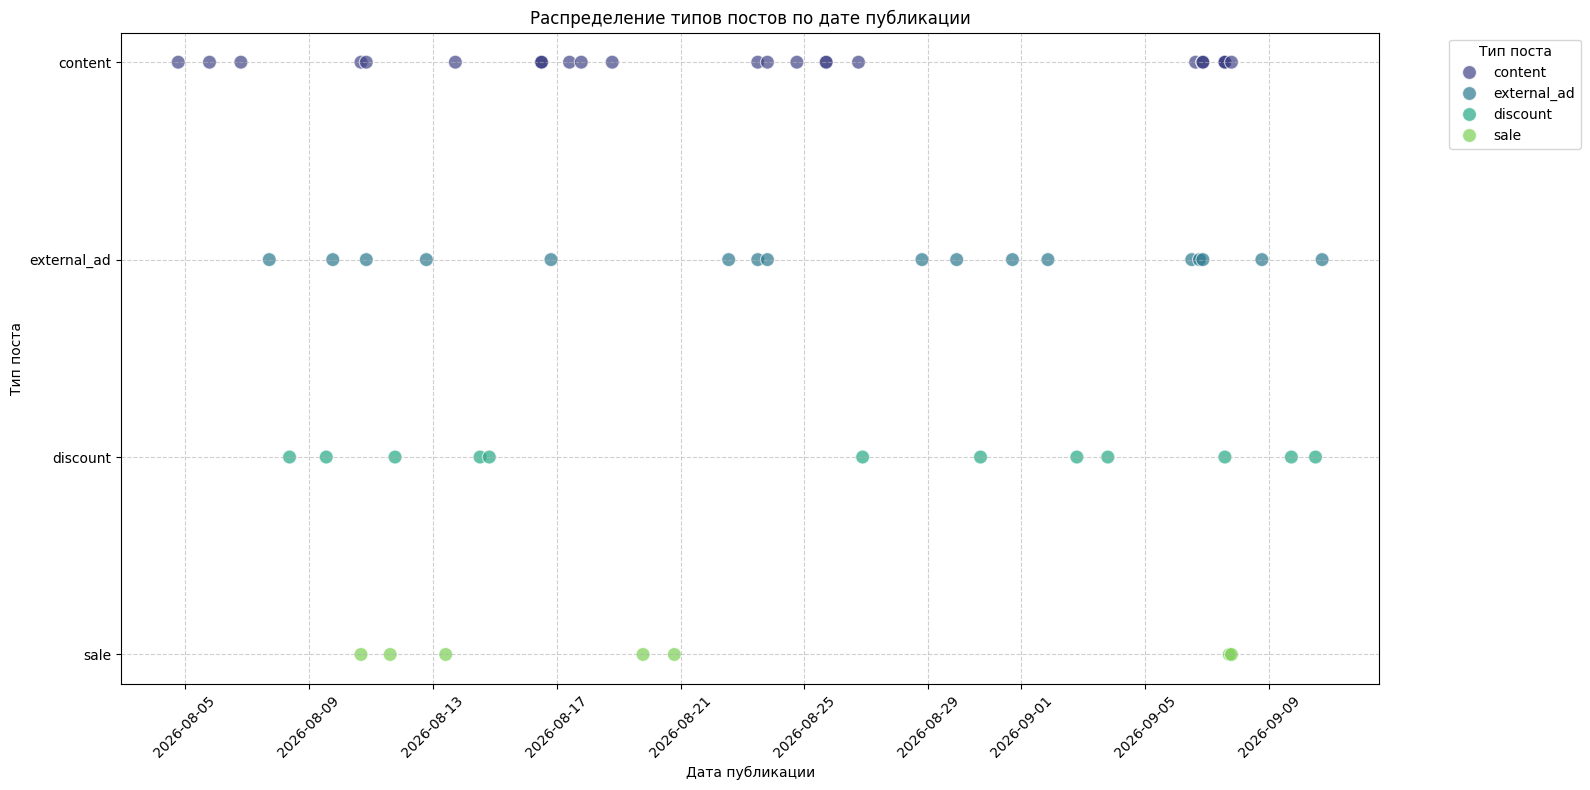

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))
sns.scatterplot(
    data=analysis_posts_classified,
    x='event_timestamp',
    y='post_type',
    hue='post_type',
    s=100, # Adjust marker size for better visibility
    palette='viridis', # Choose a color palette
    alpha=0.7 # Adjust transparency
)

plt.title('Распределение типов постов по дате публикации')
plt.xlabel('Дата публикации')
plt.ylabel('Тип поста')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Тип поста', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

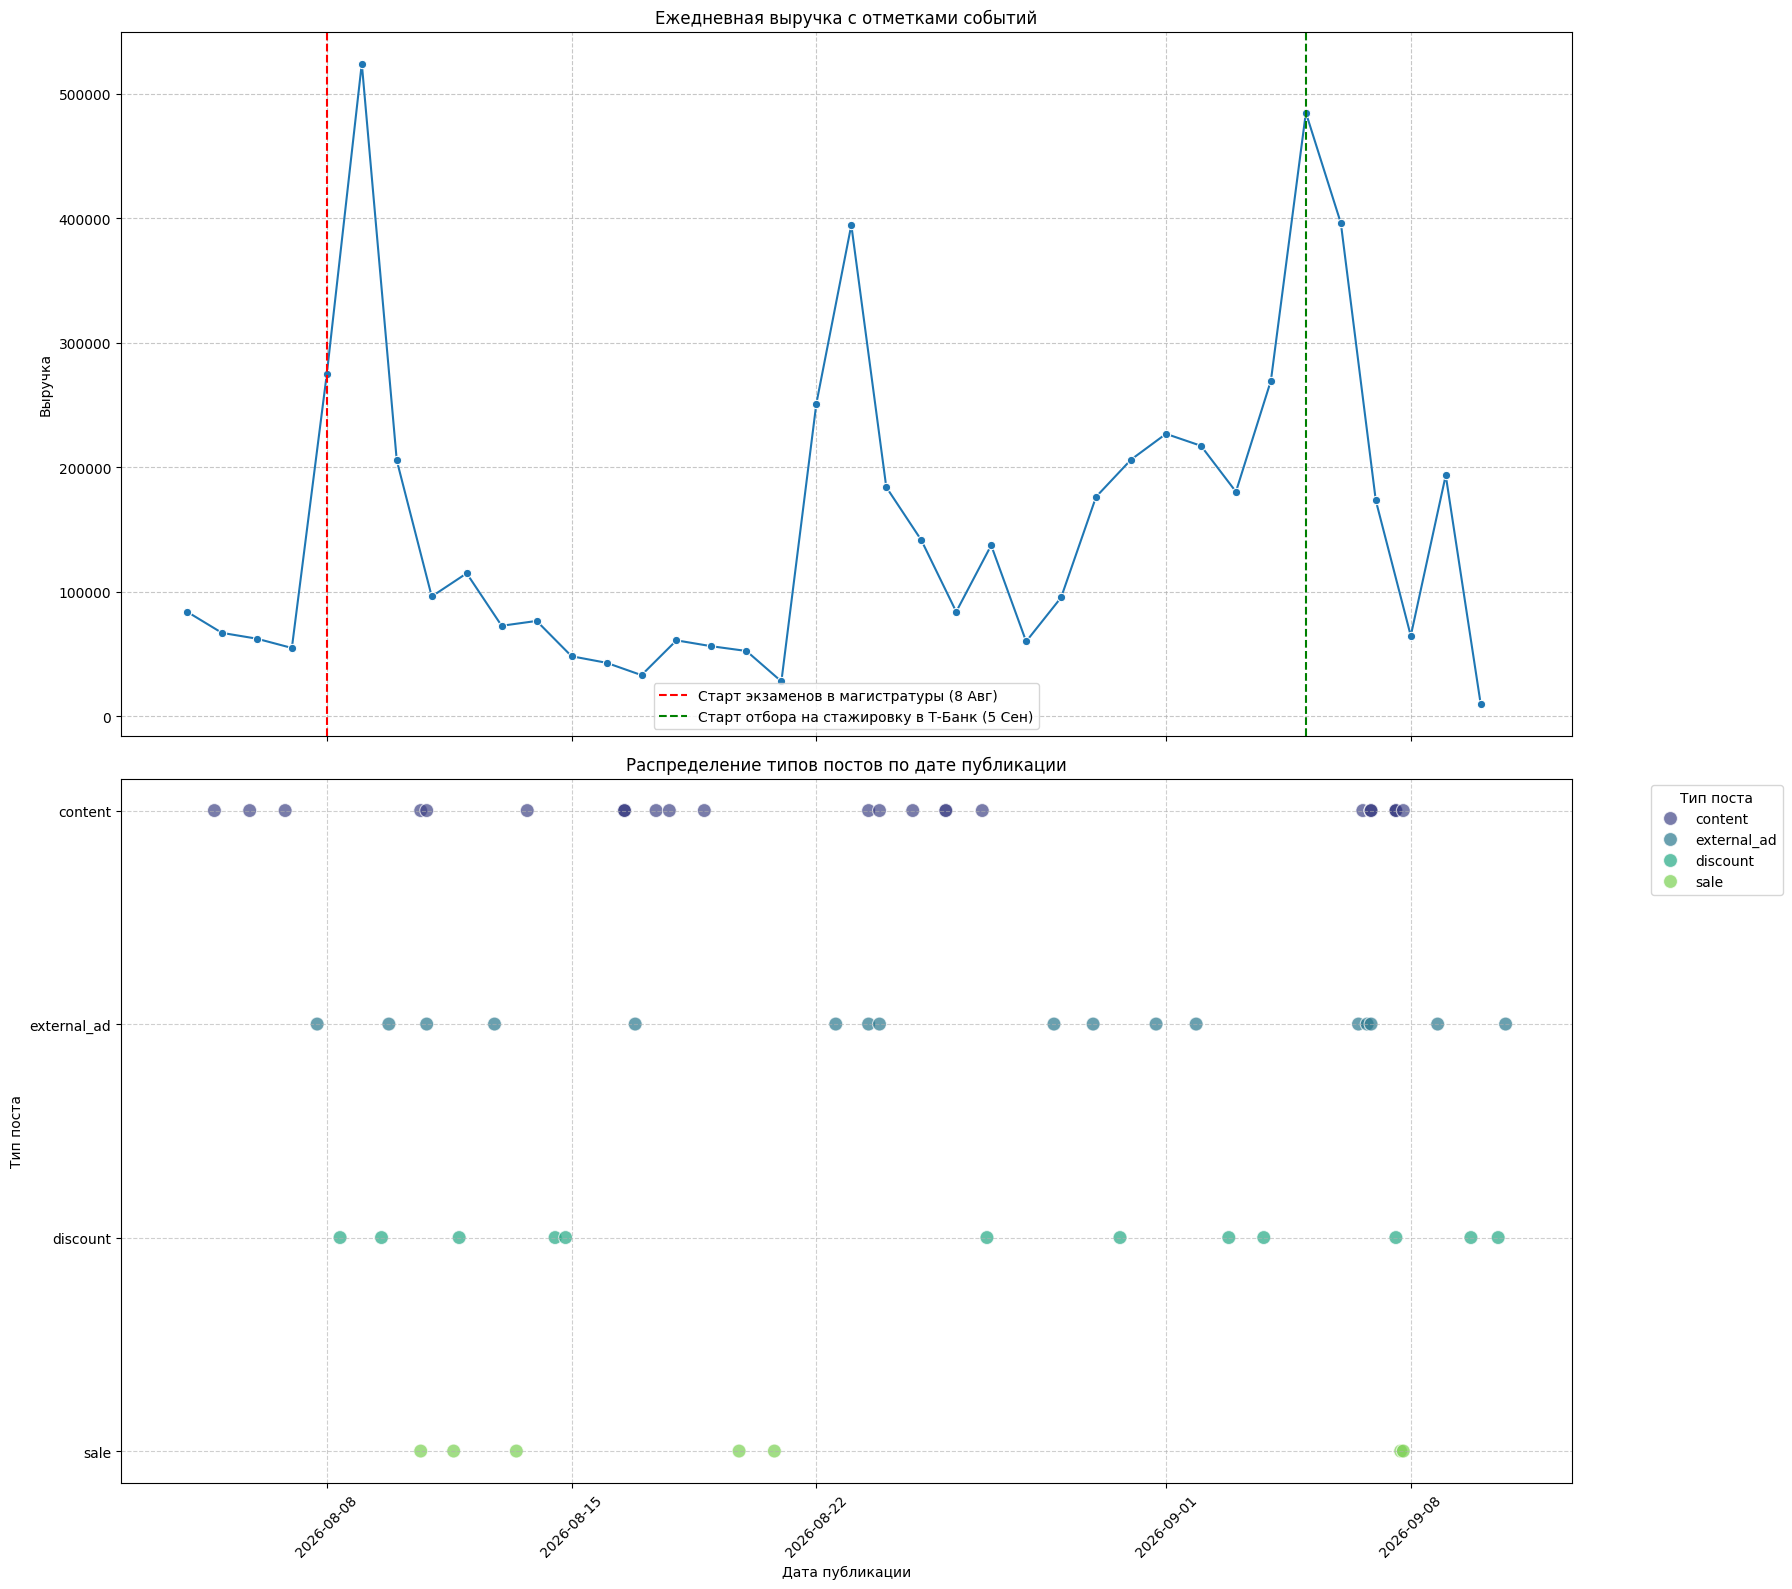

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(18, 16), sharex=True)

# --- Subplot 1: Daily Revenue with Event Markers ---
# Ensure 'Время' is datetime and then extract the date
# Assuming base_cleaned is available and 'Время' is already in datetime format
# If not, uncomment and run: base_cleaned['Время'] = pd.to_datetime(base_cleaned['Время'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
# Re-calculating daily_revenue to ensure it's up-to-date and consistent
base_cleaned['День'] = base_cleaned['Время'].dt.date
daily_revenue = base_cleaned.groupby('День')['Сумма'].sum().reset_index()

sns.lineplot(x='День', y='Сумма', data=daily_revenue, marker='o', ax=axes[0])

# Add vertical lines for specific dates (as defined previously)
exam_start_date = pd.to_datetime('2026-08-08').date()
internship_start_date = pd.to_datetime('2026-09-05').date()

axes[0].axvline(x=exam_start_date, color='r', linestyle='--', label='Старт экзаменов в магистратуры (8 Авг)')
axes[0].axvline(x=internship_start_date, color='g', linestyle='--', label='Старт отбора на стажировку в Т-Банк (5 Сен)')

axes[0].set_title('Ежедневная выручка с отметками событий')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Выручка')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# --- Subplot 2: Post Publication by Type ---
sns.scatterplot(
    data=analysis_posts_classified,
    x='event_timestamp',
    y='post_type',
    hue='post_type',
    s=100,
    palette='viridis',
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title('Распределение типов постов по дате публикации')
axes[1].set_xlabel('Дата публикации')
axes[1].set_ylabel('Тип поста')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(title='Тип поста', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45) # Apply rotation to both x-axes due to sharex=True
plt.tight_layout()
plt.show()

По публичному поиску по запросам «Поступашки», @postupashki и t.me/postupashki внешние рекламные размещения за период анализа не обнаружены. Это не доказывает отсутствие рекламы: публикации могли быть удалены, не индексироваться или не содержать название бренда. Поэтому исторический ROMI внешней рекламы рассчитать невозможно.

In [ ]:
# Таблица для постов в других каналах
# Пустая, тк поиск не дал результатов.

external_placements = pd.DataFrame(columns=[
    "placement_id",
    "channel",
    "publication_time",
    "post_url",
    "post_text",
    "mention_type",
    "views",
    "cost",
    "source",
    "notes"
])

external_placements.to_csv("external_placements.csv", index=False)